In [2]:
# 1. Kaggle APIのインストール
!pip install kaggle

# 2. kaggle.jsonを正しいディレクトリに配置し、権限を付与
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Breast Cancer Wisconsinデータセットのダウンロード
!kaggle datasets download -d uciml/breast-cancer-wisconsin-data

# 4. ダウンロードしたZIPファイルの解凍
!unzip -o breast-cancer-wisconsin-data.zip

# 5. データの読み込みと確認
import pandas as pd

# 解凍されたCSVファイルを読み込む
df = pd.read_csv('data.csv')

# データの先頭5行と、全体の形状を確認
print(f"データの形状: {df.shape}")
display(df.head())

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
License(s): CC-BY-NC-SA-4.0
100% 48.6k/48.6k [00:00<00:00, 51.2MB/s]

Archive:  breast-cancer-wisconsin-data.zip
  inflating: data.csv                
データの形状: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
print(df.isnull().sum())
print(df.shape)

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [7]:
# 1. 不要な列の削除
df = df.drop(['id', 'Unnamed: 32'], axis=1)

# 2. 目的変数（diagnosis）の数値化
# Malignant(悪性)を1, Benign(良性)を0に変換
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# 3. データの確認
print("変換後のデータ形状:", df.shape)
print("\n--- 目的変数の内訳 ---")
print(df['diagnosis'].value_counts())
display(df.head())

変換後のデータ形状: (569, 31)

--- 目的変数の内訳 ---
diagnosis
0    357
1    212
Name: count, dtype: int64


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


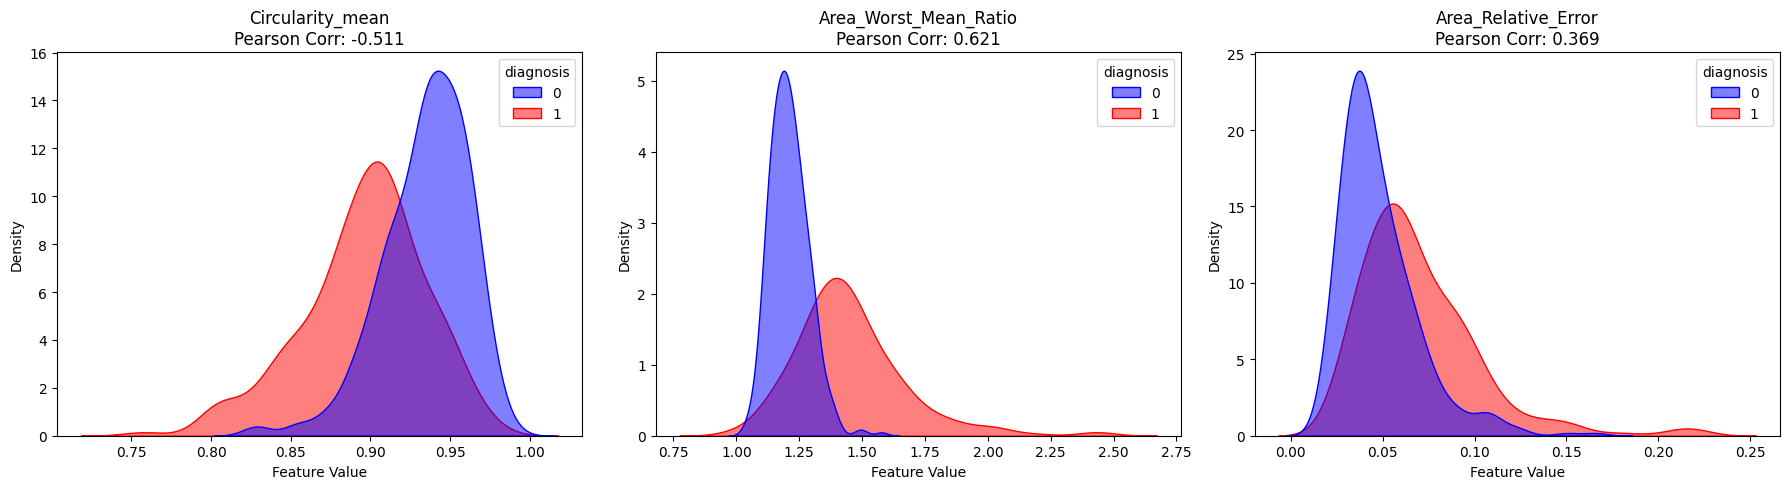

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 特徴量の作成
# 1. Circularity_mean (円形度)
df['Circularity_mean'] = (4 * np.pi * df['area_mean']) / (df['perimeter_mean'] ** 2)

# 2. Area_Worst_Mean_Ratio (最悪値と平均値の乖離率)
df['Area_Worst_Mean_Ratio'] = df['area_worst'] / df['area_mean']

# 3. Area_Relative_Error (面積の相対的なばらつき)
df['Area_Relative_Error'] = df['area_se'] / df['area_mean']

# 2. 有効性の検証 (可視化と相関係数)
new_features = ['Circularity_mean', 'Area_Worst_Mean_Ratio', 'Area_Relative_Error']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(new_features):
    # 悪性(1)と良性(0)の分布を重ねて描画するKDE（カーネル密度推定）プロット
    # 青が良性、赤が悪性
    sns.kdeplot(data=df, x=feature, hue='diagnosis', fill=True,
                common_norm=False, palette={0: 'blue', 1: 'red'}, ax=axes[i], alpha=0.5)

    # 目的変数との相関係数 (Point-Biserial Correlation)
    corr = df[feature].corr(df['diagnosis'])
    axes[i].set_title(f'{feature}\nPearson Corr: {corr:.3f}')
    axes[i].set_xlabel('Feature Value')
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()

学習データ: 398件, テストデータ: 171件

--- ランダムフォレストの評価指標 (テストデータ) ---
Accuracy  (正解率) : 0.9766 (全体のうち正解した割合)
Precision (適合率) : 1.0000 (悪性と予測した中で、本当に悪性だった割合)
Recall    (再現率) : 0.9375 (実際の悪性のうち、見逃さずに予測できた割合)
F1-score  (F1値)   : 0.9677 (PrecisionとRecallのバランス)


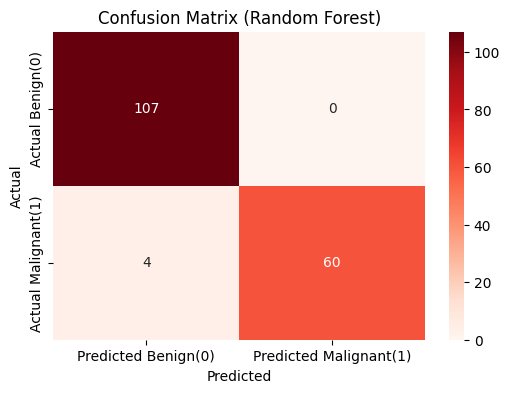


--- 特徴量の重要度 (Top 10) ---


,Feature,Importance
7,concave points_mean,0.138903
20,radius_worst,0.099953
22,perimeter_worst,0.082959
23,area_worst,0.080797
2,perimeter_mean,0.060795
26,concavity_worst,0.059607
27,concave points_worst,0.058820
6,concavity_mean,0.054702
0,radius_mean,0.053323
3,area_mean,0.051321


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']
# 1. データの分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"学習データ: {X_train.shape[0]}件, テストデータ: {X_test.shape[0]}件\n")

# 2. モデルの学習
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# 3. テストデータに対する予測
y_pred = rf_model.predict(X_test)

# 4. 評価指標の出力
print("--- ランダムフォレストの評価指標 (テストデータ) ---")
print(f"Accuracy  (正解率) : {accuracy_score(y_test, y_pred):.4f} (全体のうち正解した割合)")
print(f"Precision (適合率) : {precision_score(y_test, y_pred):.4f} (悪性と予測した中で、本当に悪性だった割合)")
print(f"Recall    (再現率) : {recall_score(y_test, y_pred):.4f} (実際の悪性のうち、見逃さずに予測できた割合)")
print(f"F1-score  (F1値)   : {f1_score(y_test, y_pred):.4f} (PrecisionとRecallのバランス)")

# 5. 混同行列の可視化
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Benign(0)', 'Predicted Malignant(1)'],
            yticklabels=['Actual Benign(0)', 'Actual Malignant(1)'])
plt.title('Confusion Matrix (Random Forest)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 6. 特徴量重要度
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- 特徴量の重要度 (Top 10) ---")
display(importances.head(10))

In [11]:
print(importances.head(10))

                 Feature  Importance
7    concave points_mean    0.138903
20          radius_worst    0.099953
22       perimeter_worst    0.082959
23            area_worst    0.080797
2         perimeter_mean    0.060795
26       concavity_worst    0.059607
27  concave points_worst    0.058820
6         concavity_mean    0.054702
0            radius_mean    0.053323
3              area_mean    0.051321


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. ランダムフォレストで上位になったトップ10特徴量のみを抽出
top_10_features = importances['Feature'].head(10).tolist()
X_train_selected = X_train[top_10_features]
X_test_selected = X_test[top_10_features]

# 2. パイプラインの構築
pipelines = {
    "SVM (Linear)": Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='linear', class_weight='balanced', random_state=42))
    ]),
    "KNN (K=5)": Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])
}

# 3. K-Fold 交差検証
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']

print("--- 学習データによるK-Fold交差検証 (5分割) の平均スコア ---")
for name, pipe in pipelines.items():
    cv_results = cross_validate(pipe, X_train_selected, y_train, cv=cv, scoring=scoring_metrics)
    print(f"【{name}】")
    print(f"  Accuracy : {cv_results['test_accuracy'].mean():.4f}")
    print(f"  Precision: {cv_results['test_precision'].mean():.4f}")
    print(f"  Recall   : {cv_results['test_recall'].mean():.4f}")
    print(f"  F1-score : {cv_results['test_f1'].mean():.4f}\n")

# 4. テストデータに対する最終評価
print("--- テストデータに対する最終評価指標 ---")
final_results = []

for name, pipe in pipelines.items():
    # 選択した特徴量で学習
    pipe.fit(X_train_selected, y_train)
    # テストデータで予測
    y_pred = pipe.predict(X_test_selected)

    final_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

# 結果の表示
final_results_df = pd.DataFrame(final_results).set_index("Model")
display(final_results_df.round(4))

--- 学習データによるK-Fold交差検証 (5分割) の平均スコア ---
【SVM (Linear)】
  Accuracy : 0.9271
  Precision: 0.8915
  Recall   : 0.9248
  F1-score : 0.9053

【KNN (K=5)】
  Accuracy : 0.9397
  Precision: 0.9324
  Recall   : 0.9115
  F1-score : 0.9183

--- テストデータに対する最終評価指標 ---


,Accuracy,Precision,Recall,F1-score
Model,,,,
SVM (Linear),0.9825,0.9841,0.9688,0.9764
KNN (K=5),0.9415,0.9821,0.8594,0.9167
